In [37]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split
#MACHINE LEARNING MODELS
from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

#MODEL EVALUATION METRICES
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


from sklearn.metrics import confusion_matrix


from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings("ignore")

In [73]:
df = pd.read_csv("C:\\Users\\User\\Downloads\\diabetes_012_health_indicators_BRFSS2015.csv (1).zip")

In [39]:
df.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [40]:
df.tail()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
253675,0.0,1.0,1.0,1.0,45.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,5.0,0.0,1.0,5.0,6.0,7.0
253676,2.0,1.0,1.0,1.0,18.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,4.0,0.0,0.0,1.0,0.0,11.0,2.0,4.0
253677,0.0,0.0,0.0,1.0,28.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,2.0,5.0,2.0
253678,0.0,1.0,0.0,1.0,23.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,5.0,1.0
253679,2.0,1.0,1.0,1.0,25.0,0.0,0.0,1.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,9.0,6.0,2.0


In [41]:
df.shape

(253680, 22)

In [42]:
df.size

5580960

In [43]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [44]:
df.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,...,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000,253680.000000
mean,0.296921,0.429001,0.424121,0.962670,28.382364,0.443169,0.040571,0.094186,0.756544,0.634256,...,0.951053,0.084177,2.511392,3.184772,4.242081,0.168224,0.440342,8.032119,5.050434,6.053875
std,0.698160,0.494934,0.494210,0.189571,6.608694,0.496761,0.197294,0.292087,0.429169,0.481639,...,0.215759,0.277654,1.068477,7.412847,8.717951,0.374066,0.496429,3.054220,0.985774,2.071148
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


In [45]:
df.columns

Index(['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='str')

In [46]:
for col in df.columns:
    if df[col].nunique() <= 10:
        print(f"\nColumn: {col}")
        print(df[col].unique())


Column: Diabetes_012
[0. 2. 1.]

Column: HighBP
[1. 0.]

Column: HighChol
[1. 0.]

Column: CholCheck
[1. 0.]

Column: Smoker
[1. 0.]

Column: Stroke
[0. 1.]

Column: HeartDiseaseorAttack
[0. 1.]

Column: PhysActivity
[0. 1.]

Column: Fruits
[0. 1.]

Column: Veggies
[1. 0.]

Column: HvyAlcoholConsump
[0. 1.]

Column: AnyHealthcare
[1. 0.]

Column: NoDocbcCost
[0. 1.]

Column: GenHlth
[5. 3. 2. 4. 1.]

Column: DiffWalk
[1. 0.]

Column: Sex
[0. 1.]

Column: Education
[4. 6. 3. 5. 2. 1.]

Column: Income
[3. 1. 8. 6. 4. 7. 2. 5.]


## Check Missing Values

In [47]:
df.isnull().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [48]:
print(df.duplicated().sum())

23899


## Remove Duplicates

In [49]:
df.drop_duplicates(inplace=True)

## Feature Selection

In [50]:
df.drop(columns=["CholCheck","AnyHealthcare","NoDocbcCost"],inplace=True)

In [51]:
df.head()

,Diabetes_012,HighBP,HighChol,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Outlier Detection

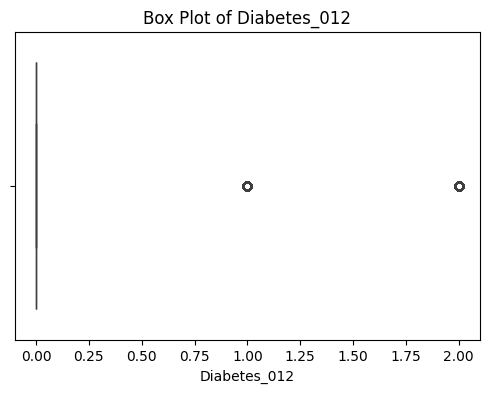

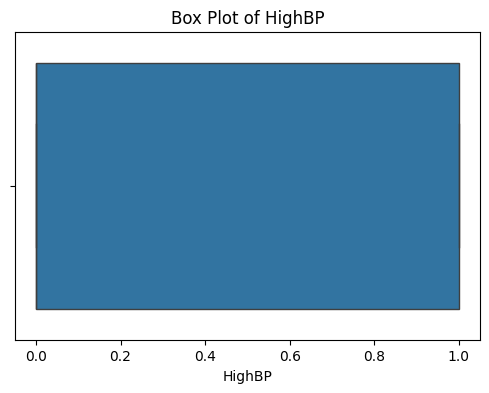

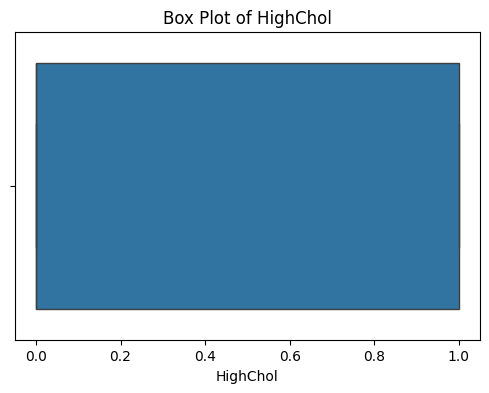

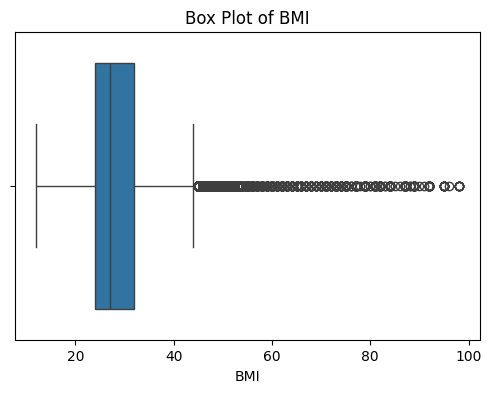

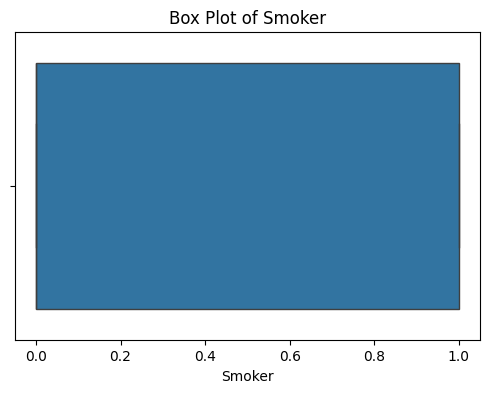

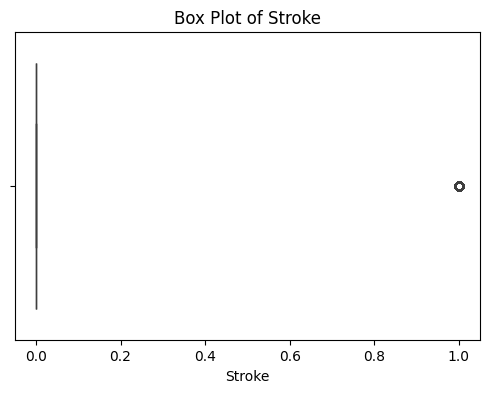

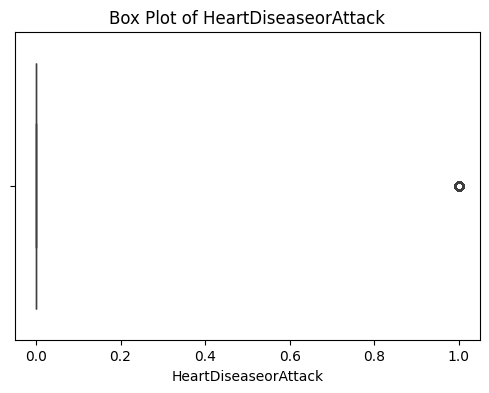

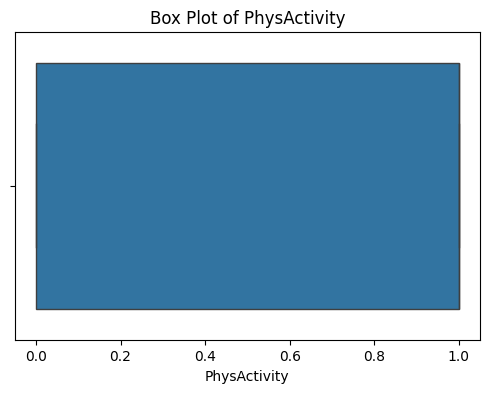

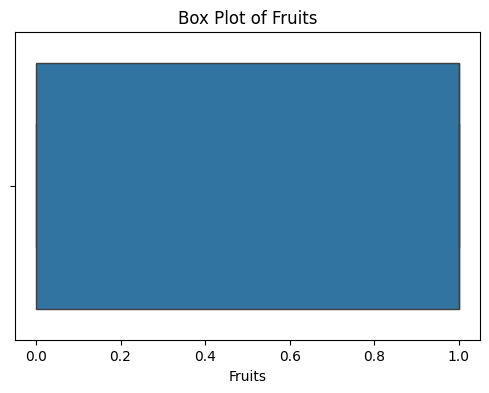

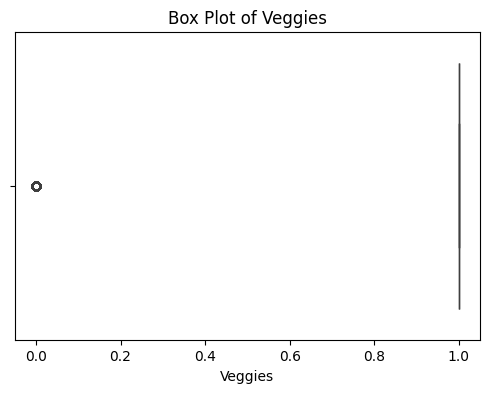

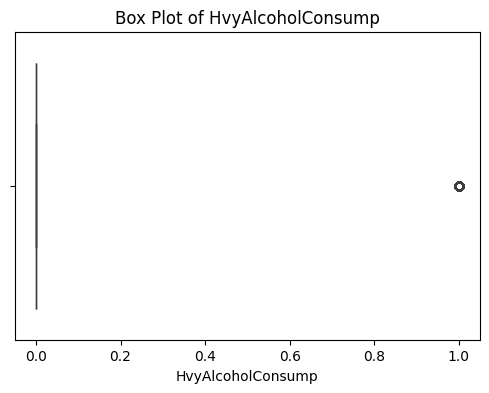

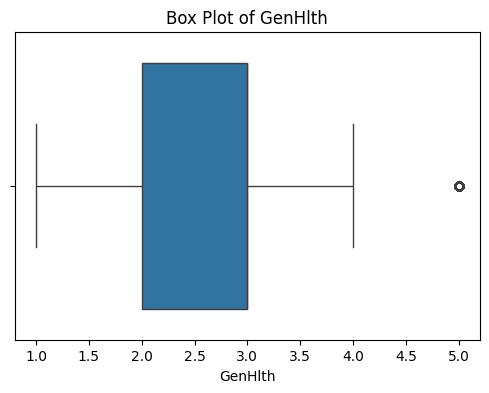

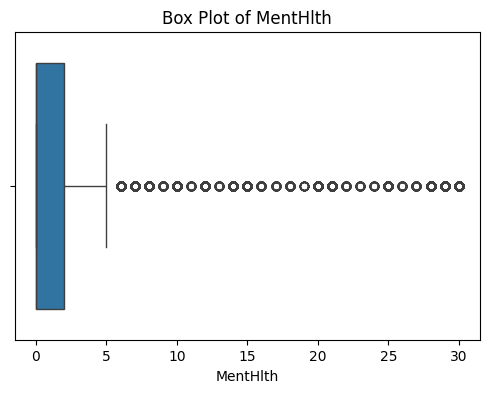

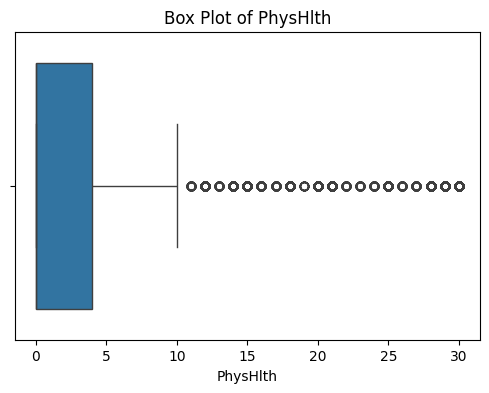

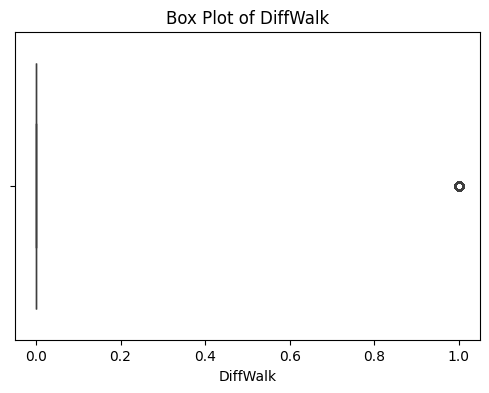

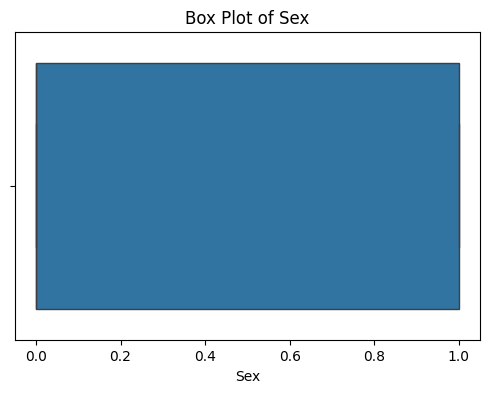

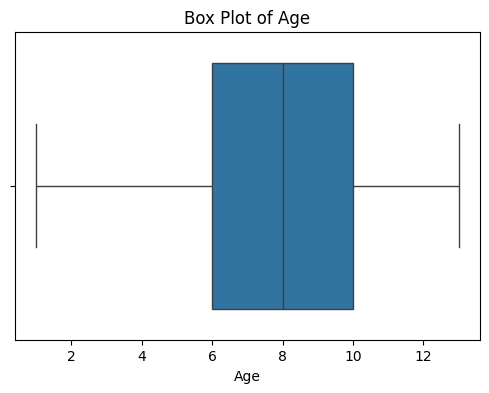

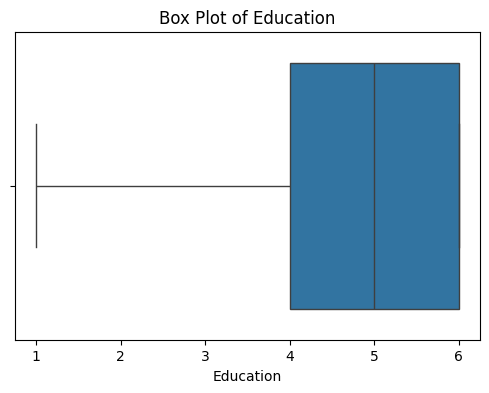

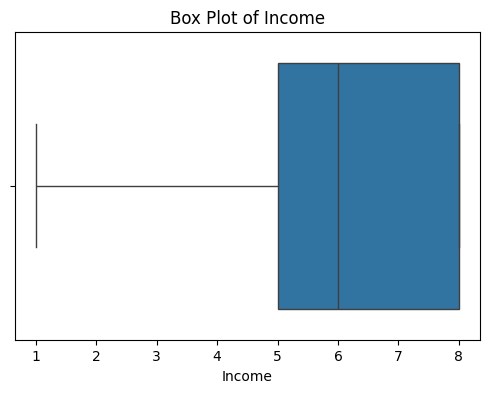

In [52]:
numerical_columns = df.select_dtypes(include=['float64']).columns
for col in numerical_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.show()

## Outlier Handling

In [68]:
out=df.drop(columns=["Diabetes_012","Stroke","HeartDiseaseorAttack","Veggies","HvyAlcoholConsump","DiffWalk"])
#numerical_columns = df.select_dtypes(include=['float64']).columns.drop("Diabetes_012")
for col in out:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3-Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.clip(df[col],lower_bound,upper_bound)
print("Outlier clipping completed.")    

Outlier clipping completed.


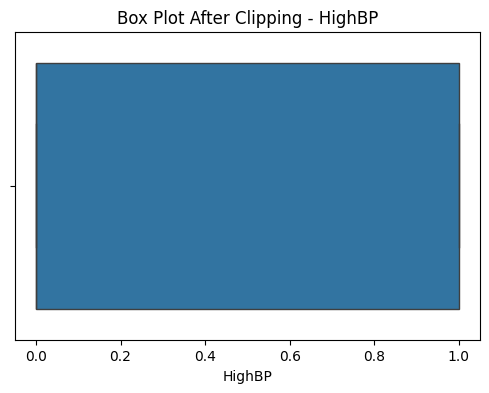

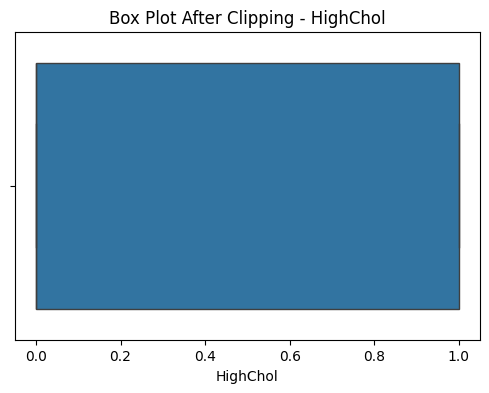

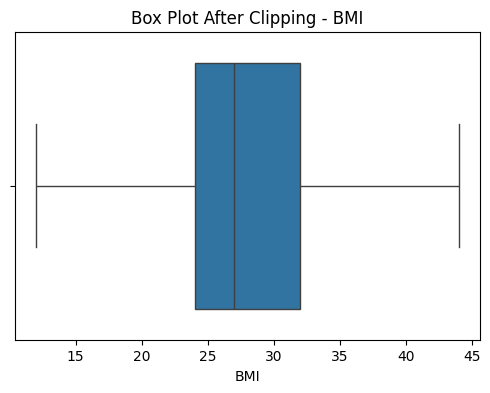

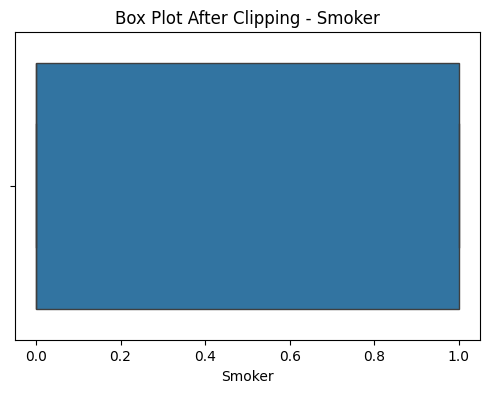

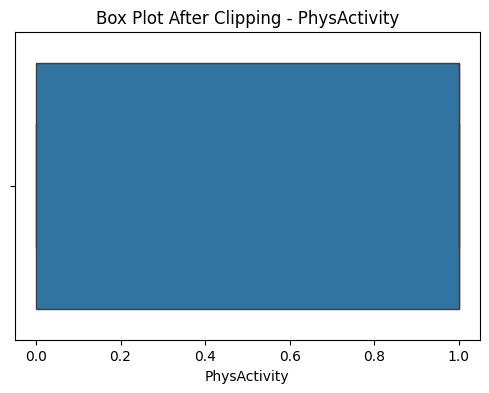

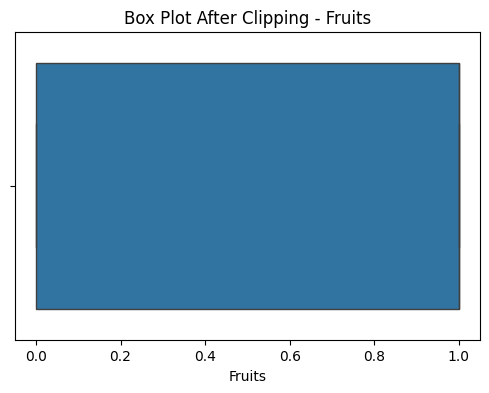

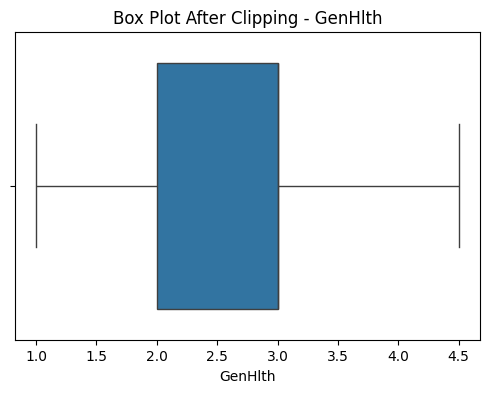

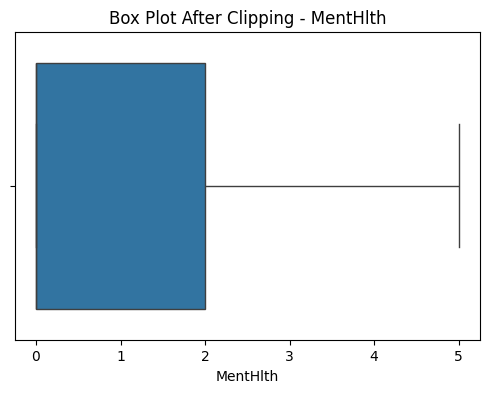

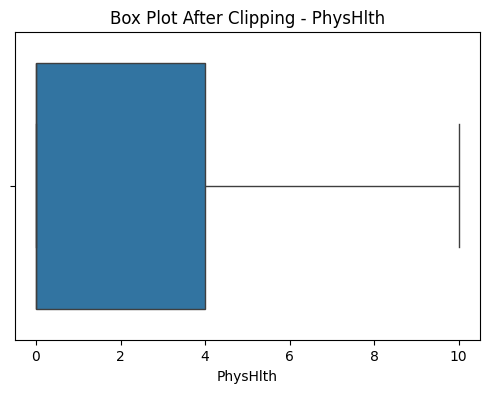

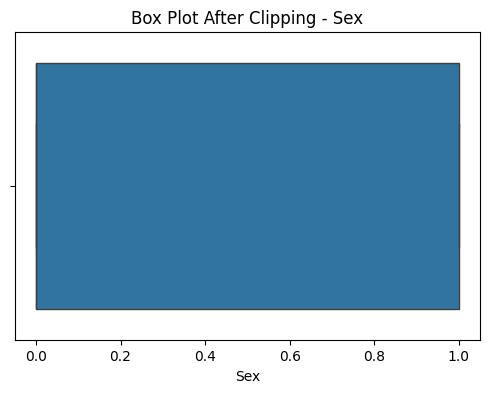

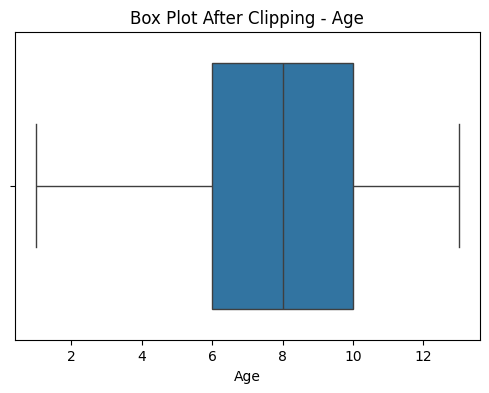

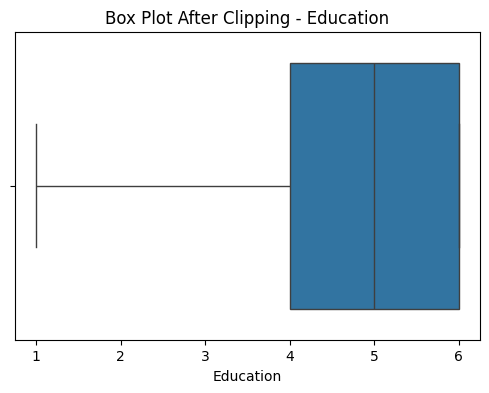

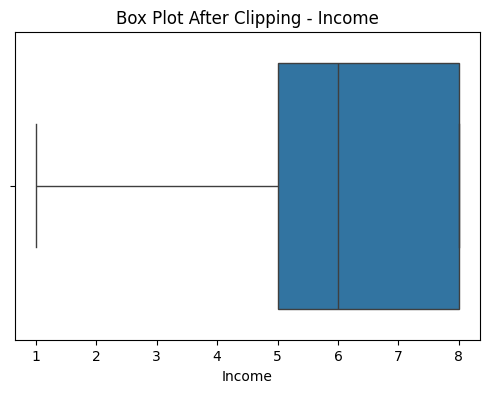

In [69]:
for col in out:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot After Clipping - {col}")
    plt.show()

## Diabetes count

In [75]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

# Insight
##### Most individuals 213,703 out of 253,680 do not have diabetes,while 35346 have diabetes and only 4,631 are classified as prediabetes


In [74]:
df.groupby("BMI")["Diabetes_012"].mean()

BMI
12.0    0.000000
13.0    0.238095
14.0    0.219512
15.0    0.181818
16.0    0.120690
          ...   
91.0    0.000000
92.0    0.312500
95.0    0.166667
96.0    1.000000
98.0    0.857143
Name: Diabetes_012, Length: 84, dtype: float64

# Insight
##### BMI=12(Avg diabetes value is 0-no diabetes)
##### BMI=96(Avg diabetes value is 1-higher diabetes presence)

## Correlation Matrix

In [76]:
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
Diabetes_012,1.000000,0.271596,0.209085,0.067546,0.224379,0.062914,0.107179,0.180272,-0.121947,-0.042192,...,0.015410,0.035436,0.302587,0.073507,0.176287,0.224239,0.031040,0.185026,-0.130517,-0.171483
HighBP,0.271596,1.000000,0.298199,0.098508,0.213748,0.096991,0.129575,0.209361,-0.125267,-0.040555,...,0.038425,0.017358,0.300530,0.056456,0.161212,0.223618,0.052207,0.344452,-0.141358,-0.171235
HighChol,0.209085,0.298199,1.000000,0.085642,0.106722,0.091299,0.092620,0.180765,-0.078046,-0.040859,...,0.042230,0.013310,0.208426,0.062069,0.121751,0.144672,0.031205,0.272318,-0.070802,-0.085459
CholCheck,0.067546,0.098508,0.085642,1.000000,0.034495,-0.009929,0.024158,0.044206,0.004190,0.023849,...,0.117626,-0.058255,0.046589,-0.008366,0.031775,0.040585,-0.022115,0.090321,0.001510,0.014259
BMI,0.224379,0.213748,0.106722,0.034495,1.000000,0.013804,0.020153,0.052904,-0.147294,-0.087518,...,-0.018471,0.058206,0.239185,0.085310,0.121141,0.197078,0.042950,-0.036618,-0.103932,-0.100069
Smoker,0.062914,0.096991,0.091299,-0.009929,0.013804,1.000000,0.061173,0.114441,-0.087401,-0.077666,...,-0.023251,0.048946,0.163143,0.092196,0.116460,0.122463,0.093662,0.120641,-0.161955,-0.123937
Stroke,0.107179,0.129575,0.092620,0.024158,0.020153,0.061173,1.000000,0.203002,-0.069151,-0.013389,...,0.008776,0.034804,0.177942,0.070172,0.148944,0.176567,0.002978,0.126974,-0.076009,-0.128599
HeartDiseaseorAttack,0.180272,0.209361,0.180765,0.044206,0.052904,0.114441,0.203002,1.000000,-0.087299,-0.019790,...,0.018734,0.031000,0.258383,0.064621,0.181698,0.212709,0.086096,0.221618,-0.099600,-0.141011
PhysActivity,-0.121947,-0.125267,-0.078046,0.004190,-0.147294,-0.087401,-0.069151,-0.087299,1.000000,0.142756,...,0.035505,-0.061638,-0.266186,-0.125587,-0.219230,-0.253174,0.032482,-0.092511,0.199658,0.198539
Fruits,-0.042192,-0.040555,-0.040859,0.023849,-0.087518,-0.077666,-0.013389,-0.019790,0.142756,1.000000,...,0.031544,-0.044243,-0.103854,-0.068217,-0.044633,-0.048352,-0.091175,0.064547,0.110187,0.079929


# Insight
#### The correlation matrix shows the strength and direction of relationships between numerical features

## Correlation Heatmap

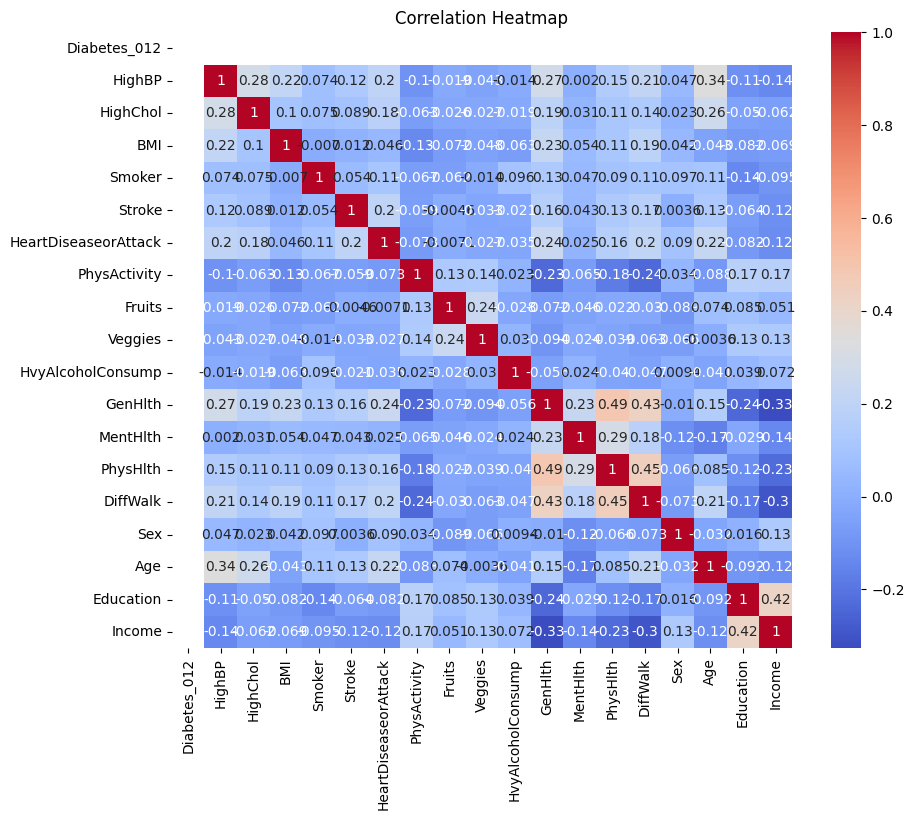

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Insight
#### Features with darker colors indicate stronger positive or negative correlations with other variables

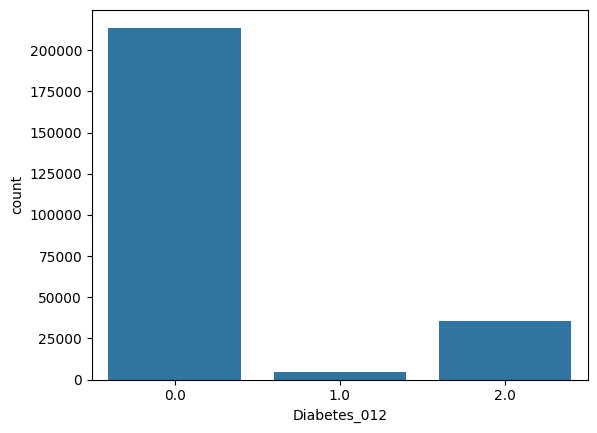

In [77]:
sns.countplot(x="Diabetes_012",data=df)
plt.show()

# Insight
#### The count of non diabetic people is significantly higher than diabetic people

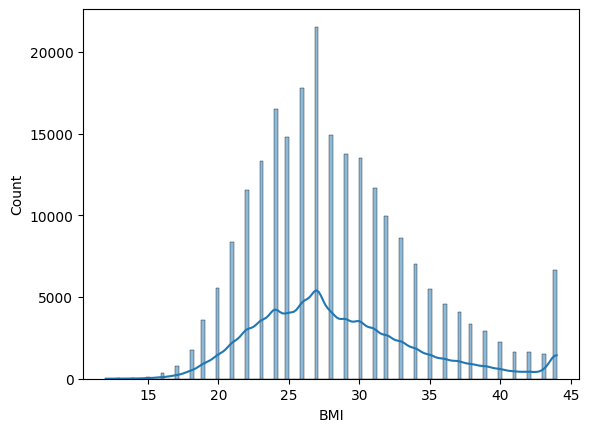

In [61]:
sns.histplot(df["BMI"],kde=True)
plt.show()

## BOX PLOT

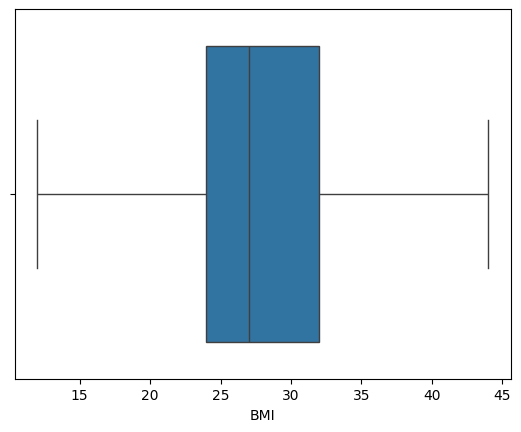

In [62]:
sns.boxplot(x=df["BMI"])
plt.show()

## Scatter Plot

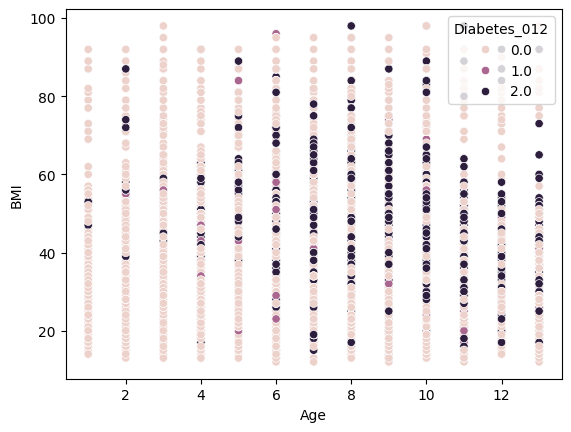

In [78]:
sns.scatterplot(x="Age",y="BMI",hue="Diabetes_012",data=df)
plt.show()

In [79]:
df["Diabetes_012"].value_counts()

Diabetes_012
0.0    213703
2.0     35346
1.0      4631
Name: count, dtype: int64

# Insight
#### Across all adult age groups,people with diabetes are mostly found higher up 

## Pair Plot

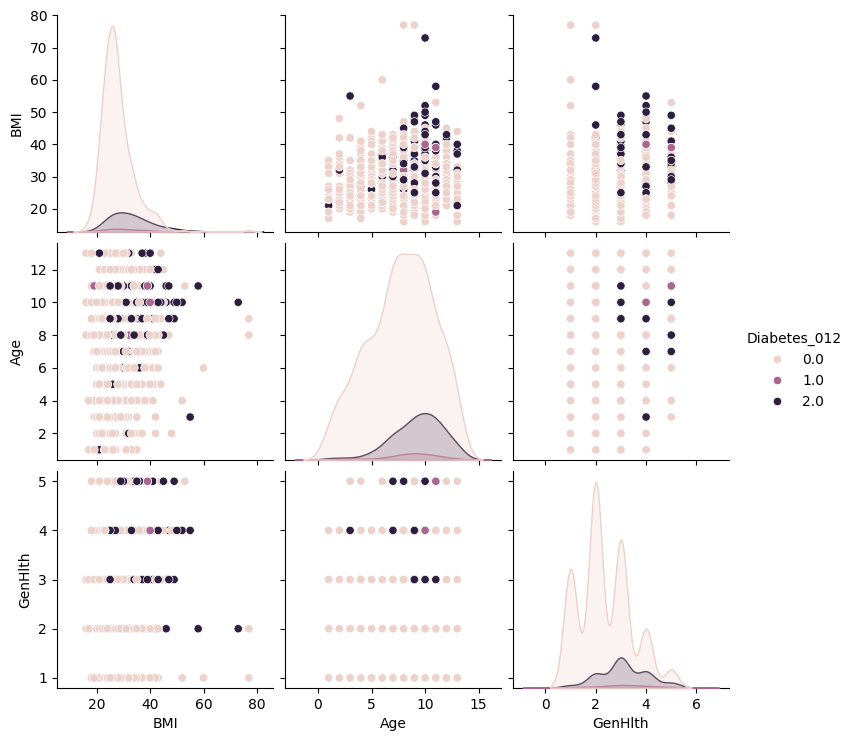

In [80]:
sample_df = df.sample(1000,random_state=42)
sns.pairplot(sample_df[["BMI","Age","GenHlth","Diabetes_012"]],hue="Diabetes_012")
plt.show()

# Insight
#### people with diabetes usually have higher body weights and poorer health across all ages

## SCALING

In [84]:
X = df.drop("Diabetes_012", axis=1)

y = df["Diabetes_012"]
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

X_scaled.head()


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,1.153688,1.165254,0.196922,1.757936,1.120927,-0.205637,-0.322458,-1.762814,-1.316872,0.482087,...,0.226863,-0.303173,2.329121,1.998592,1.233999,2.223615,-0.887021,0.316900,-1.065595,-1.474487
1,-0.866785,-0.858182,-5.078164,-0.511806,1.120927,-0.205637,-0.322458,0.567275,-1.316872,-2.074316,...,-4.407954,3.298445,0.457294,-0.429630,-0.486592,-0.449718,-0.887021,-0.337933,0.963272,-2.440138
2,1.153688,1.165254,0.196922,-0.057858,-0.892119,-0.205637,-0.322458,-1.762814,0.759375,-2.074316,...,0.226863,3.298445,2.329121,3.617407,2.954590,2.223615,-0.887021,0.316900,-1.065595,0.939638
3,1.153688,-0.858182,0.196922,-0.209174,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,-0.478619,-0.429630,-0.486592,-0.449718,-0.887021,0.971733,-2.080028,-0.026012
4,1.153688,1.165254,0.196922,-0.663122,-0.892119,-0.205637,-0.322458,0.567275,0.759375,0.482087,...,0.226863,-0.303173,-0.478619,-0.024926,-0.486592,-0.449718,-0.887021,0.971733,-0.051162,-0.991662


## Train-Test Split

In [85]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(X_test.shape)

(202944, 21)
(50736, 21)


## Logistic Reggression Model

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr = LogisticRegression(random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))


Logistic Regression Accuracy : 0.8449621570482497


## Decision Tree Classifier

In [87]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
print("Decision Tree Accuracy :", accuracy_score(y_test, dt_pred))


Decision Tree Accuracy : 0.7673446862188584


## Random Forest

In [88]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
print("Random Forest Accuracy :", accuracy_score(y_test, rf_pred))

Random Forest Accuracy : 0.8412172816146326


## KNN

In [89]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
print("KNN Accuracy :", accuracy_score(y_test, knn_pred))


KNN Accuracy : 0.8333530432040366


In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy :", accuracy_score(y_test, svm_pred))

## Model Accuracy Score

In [ ]:
print("Logistic Regression Accuracy :", accuracy_score(y_test, lr_pred))
print("Decision Tree Accuracy       :", accuracy_score(y_test, dt_pred))
print("Random Forest Accuracy       :", accuracy_score(y_test, rf_pred))
print("KNN Accuracy                 :", accuracy_score(y_test, knn_pred))


Logistic Regression Accuracy : 0.8449621570482497
Decision Tree Accuracy       : 0.7673446862188584
Random Forest Accuracy       : 0.8412172816146326
KNN Accuracy                 : 0.8333530432040366


In [ ]:
from sklearn.svm import SVC

svm = SVC(random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
print("SVM Accuracy :", accuracy_score(y_test, svm_pred))

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
gbc=GradientBoost

# Insight
#### Logistic Regression achieved highest accuracy among all the evaluated models
#### Logistic Regression was selected as final model

## Confusion Matrix

In [90]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, lr_pred)

print(cm)

[[41785     0  1010]
 [  878     0    66]
 [ 5912     0  1085]]


## Heatmap with Labels

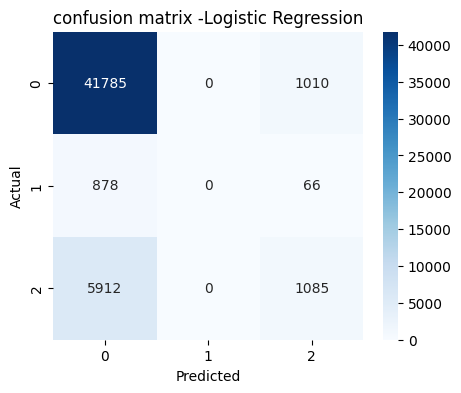

In [91]:
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("confusion matrix -Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Classification Report

In [92]:
from sklearn.metrics import classification_report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

         0.0       0.86      0.98      0.91     42795
         1.0       0.00      0.00      0.00       944
         2.0       0.50      0.16      0.24      6997

    accuracy                           0.84     50736
   macro avg       0.45      0.38      0.38     50736
weighted avg       0.79      0.84      0.80     50736



## Prediction

In [93]:
sample = X.iloc[1:10]

predictions = lr.predict(sample)

results = pd.DataFrame({
    "Actual": y.iloc[1:10].values,
    "Predicted": predictions
})

print(results)

   Actual  Predicted
0     0.0        0.0
1     0.0        0.0
2     0.0        0.0
3     0.0        0.0
4     0.0        0.0
5     0.0        0.0
6     0.0        0.0
7     2.0        2.0
8     0.0        0.0
